## Hypothesis Testing Report

**Dataset:** final_df.csv | 75,925 records | 13 features tested  
**Target:** Prospect_Outcome (Won / Churned)  
**Scenario:** Churn Prediction — Prospect_Outcome vs Customer Care Features


## Table of Contents

1. Setup & Imports
2. Data Loading & Preprocessing
3. Feature Overview & Test Strategy
4. Direction (Chi-Square)
5. cc_business_struggles_financial_hardship (Chi-Square)
6. cc_dissatisfaction_support (Chi-Square)
7. cc_contractor_sentiment (Chi-Square)
8. cc_contractor_sentiment_issues_score (Mann-Whitney U)
9. cc_pricing_sentiment_impact (Chi-Square + Fisher's Exact)
10. cc_refund_discussed (Chi-Square + Fisher's Exact)
11. cc_contractor_complained (Chi-Square + Fisher's Exact)
12. Summary Results Table
13. Visualisation Dashboard


## Section 1 — Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import (
    chi2_contingency,
    fisher_exact,
    mannwhitneyu,
    shapiro,
    pointbiserialr
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SIG_LEVEL = 0.05

print('All libraries loaded successfully')

All libraries loaded successfully


## Section 2 — Data Loading & Preprocessing


In [2]:
df = pd.read_csv('final_df.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')


Dataset shape: (75925, 14)
Columns: ['Co_Ref', 'Prospect_Outcome', 'Prospect_Renewal_Date', 'Contact_ID', 'Call_Date', 'Direction', 'cc_business_struggles_financial_hardship', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_contractor_sentiment_issues_score', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_complained', 'Analysed_Call']


In [3]:
target_counts = df['Prospect_Outcome'].value_counts()
target_pct    = df['Prospect_Outcome'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
print('\nTarget Variable - Prospect_Outcome')
print('='*40)
print(summary)
print(f'\nClass Ratio Won : Churned = {target_counts["Won"]/target_counts["Churned"]:.1f} : 1')


Target Variable - Prospect_Outcome
                  Count  Percentage (%)
Prospect_Outcome                       
Won               64096         84.4200
Churned           11829         15.5800

Class Ratio Won : Churned = 5.4 : 1


In [4]:
df['target_binary'] = (df['Prospect_Outcome'] == 'Churned').astype(int)

df['sentiment_score_num'] = pd.to_numeric(
    df['cc_contractor_sentiment_issues_score'], errors='coerce'
)

won_df     = df[df['Prospect_Outcome'] == 'Won'].copy()
churned_df = df[df['Prospect_Outcome'] == 'Churned'].copy()

print(f'Won group rows    : {len(won_df):,}')
print(f'Churned group rows: {len(churned_df):,}')
print(f'Sentiment score numeric values: {df["sentiment_score_num"].notna().sum():,}')
print('\nPreprocessing complete')

Won group rows    : 64,096
Churned group rows: 11,829
Sentiment score numeric values: 1,085

Preprocessing complete


## Section 3 — Feature Overview & Test Strategy

The table below summarises the test strategy for each feature based on its data type and distribution characteristics.

| Feature | Type | Test | Rationale |
|---------|------|------|----------|
| `Direction` | Binary Categorical | Chi-Square | 2 independent nominal groups vs binary target |
| `cc_business_struggles_financial_hardship` | Multi-class Categorical | Chi-Square | 3-level nominal vs binary target |
| `cc_dissatisfaction_support` | Multi-class Categorical | Chi-Square | 3-level nominal vs binary target |
| `cc_contractor_sentiment` | Multi-class Categorical | Chi-Square | 4-level ordinal-ish vs binary target |
| `cc_contractor_sentiment_issues_score` | Numeric (Discrete) | Mann-Whitney U | Non-normal distribution; non-parametric rank test appropriate |
| `cc_pricing_sentiment_impact` | Binary Categorical | Chi-Square + Fisher's Exact | 2×2 table; Fisher's Exact validates when cells may be small |
| `cc_refund_discussed` | Binary Categorical | Chi-Square + Fisher's Exact | 2×2 table |
| `cc_contractor_complained` | Binary Categorical | Chi-Square + Fisher's Exact | 2×2 table |

**Significance level α = 0.05** for all tests.  
**Effect size** is reported alongside p-values — statistical significance alone is insufficient for large datasets.


In [5]:
def interpret(p_val, alpha=0.05):
    if p_val < alpha:
        return f'SIGNIFICANT (p={p_val:.4f} < {alpha})'
    else:
        return f'NOT SIGNIFICANT (p={p_val:.4f} >= {alpha})'

def cramers_v(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def effect_label(v, test='cramers'):
    if test == 'cramers':
        if v < 0.10:  return 'Negligible'
        elif v < 0.30: return 'Small'
        elif v < 0.50: return 'Medium'
        else:          return 'Large'
    elif test == 'rb':
        av = abs(v)
        if av < 0.10:  return 'Negligible'
        elif av < 0.30: return 'Small'
        elif av < 0.50: return 'Medium'
        else:           return 'Large'

results = []

print('Helper functions defined')

Helper functions defined


## Section 4 — Direction — Chi-Square Test

**Feature description:** Whether the customer care call was outbound (agent-initiated) or inbound (customer-initiated).

**H₀ (Null Hypothesis):** There is no association between call direction and churn outcome.  
**H₁ (Alternative Hypothesis):** Call direction is significantly associated with churn outcome.

**Test chosen:** Chi-Square Test of Independence — both variables are nominal categorical.


In [6]:
print('\n' + '='*65)
print('Direction × Prospect_Outcome | Chi-Square Test')
print('='*65)

feat = 'Direction'
sub = df[df[feat].isin(['IN_BOUND','OUT_BOUND'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
print('\nContingency Table (counts):')
print(ct)

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print('\nContingency Table (row %):')
print(ct_pct.round(2))

chi2, p, dof, expected = chi2_contingency(ct)
v = cramers_v(ct)

print(f'\nChi-Square Statistic: {chi2:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'p-value: {p:.6f}')
print(f"Cramers V: {v:.4f} ({effect_label(v)})")
print(f'\n{interpret(p)}')

results.append({'Feature': feat, 'Test': 'Chi-Square', 'Statistic': round(chi2,4),
                'p-value': round(p,6), 'Effect Size': round(v,4),
                'Effect Label': effect_label(v), 'Significant': p < SIG_LEVEL})


Direction × Prospect_Outcome | Chi-Square Test

Contingency Table (counts):
Prospect_Outcome  Churned   Won
Direction                      
IN_BOUND               64   661
OUT_BOUND             169  2243

Contingency Table (row %):
Prospect_Outcome  Churned     Won
Direction                        
IN_BOUND           8.8300 91.1700
OUT_BOUND          7.0100 92.9900

Chi-Square Statistic: 2.4300
Degrees of Freedom: 1
p-value: 0.119035
Cramers V: 0.0278 (Negligible)

NOT SIGNIFICANT (p=0.1190 >= 0.05)


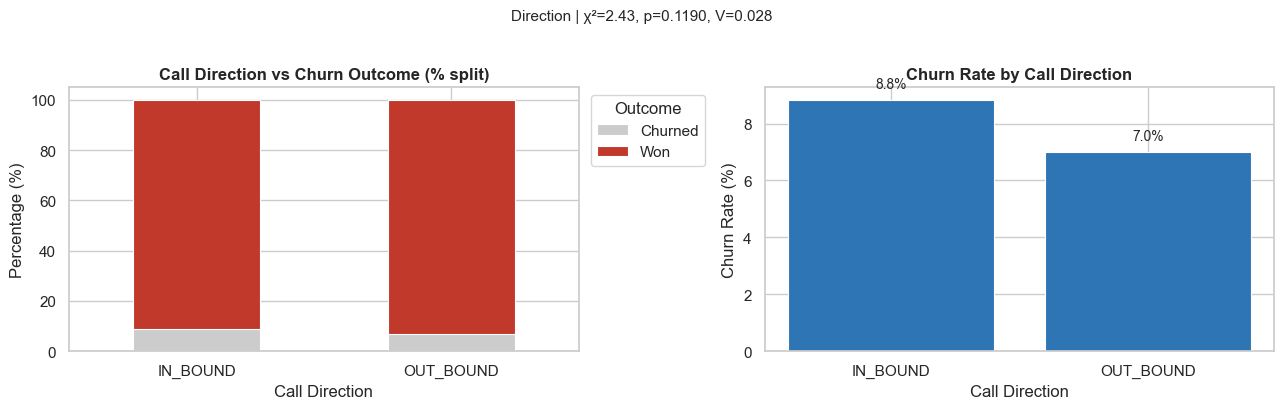

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Call Direction vs Churn Outcome (% split)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Call Direction')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'],
                   color='#2E75B6', edgecolor='white', linewidth=0.8)
axes[1].set_title('Churn Rate by Call Direction', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Call Direction')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Direction | χ²={chi2:.2f}, p={p:.4f}, V={v:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 5 — cc_business_struggles_financial_hardship — Chi-Square Test

**Feature description:** Whether the customer mentioned financial hardship or business struggles during the call.

**H₀:** Financial hardship mention is independent of churn outcome.  
**H₁:** Financial hardship mention is significantly associated with churn outcome.

**Test chosen:** Chi-Square — 3-level nominal variable (Yes / No / Unknown) vs binary target.


In [8]:
print('\n' + '='*65)
print('cc_business_struggles_financial_hardship × Prospect_Outcome')
print('='*65)

feat = 'cc_business_struggles_financial_hardship'
sub = df[df[feat].isin(['Yes','No','Unknown'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_biz, p_biz, dof_biz, _ = chi2_contingency(ct)
v_biz = cramers_v(ct)

print(f'\nChi-Square Statistic: {chi2_biz:.4f}')
print(f'Degrees of Freedom: {dof_biz}')
print(f'p-value: {p_biz:.6f}')
print(f"Cramers V: {v_biz:.4f} ({effect_label(v_biz)})")
print(f'\n{interpret(p_biz)}')

results.append({'Feature': feat, 'Test': 'Chi-Square', 'Statistic': round(chi2_biz,4),
                'p-value': round(p_biz,6), 'Effect Size': round(v_biz,4),
                'Effect Label': effect_label(v_biz), 'Significant': p_biz < SIG_LEVEL})


cc_business_struggles_financial_hardship × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome                          Churned   Won
cc_business_struggles_financial_hardship               
No                                            202  2798
Unknown                                         1    13
Yes                                            30    93

Row percentages:
Prospect_Outcome                          Churned     Won
cc_business_struggles_financial_hardship                 
No                                         6.7300 93.2700
Unknown                                    7.1400 92.8600
Yes                                       24.3900 75.6100

Chi-Square Statistic: 53.5764
Degrees of Freedom: 2
p-value: 0.000000
Cramers V: 0.1307 (Small)

SIGNIFICANT (p=0.0000 < 0.05)


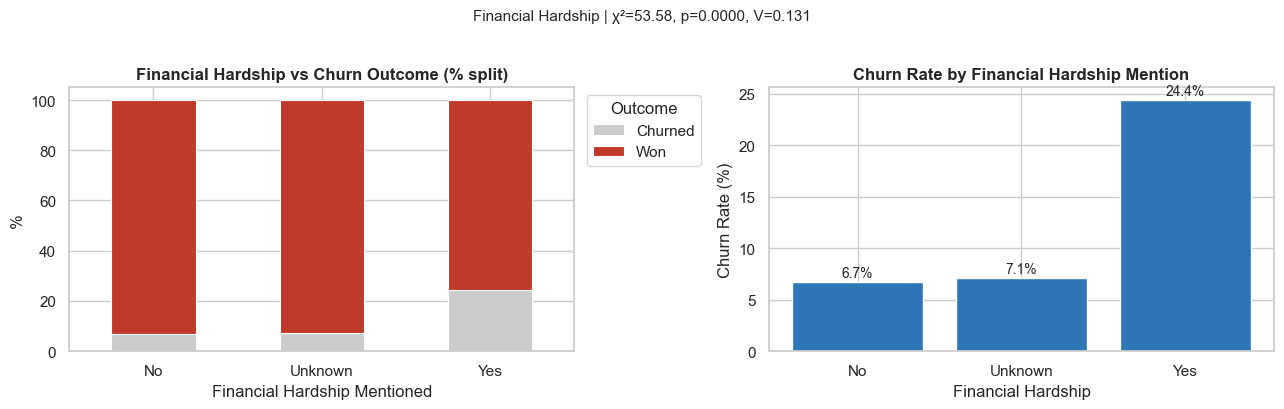

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Financial Hardship vs Churn Outcome (% split)', fontweight='bold')
axes[0].set_xlabel('Financial Hardship Mentioned')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'],
                   color='#2E75B6', edgecolor='white')
axes[1].set_title('Churn Rate by Financial Hardship Mention', fontweight='bold')
axes[1].set_xlabel('Financial Hardship')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Financial Hardship | χ²={chi2_biz:.2f}, p={p_biz:.4f}, V={v_biz:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 6 — cc_dissatisfaction_support — Chi-Square Test

**Feature description:** Whether the customer expressed dissatisfaction with the level of support received.

**H₀:** Support dissatisfaction is independent of churn outcome.  
**H₁:** Support dissatisfaction is significantly associated with churn outcome.

**Test chosen:** Chi-Square — 3-level nominal (Yes / No / Unknown) vs binary target.


In [10]:
print('\n' + '='*65)
print('cc_dissatisfaction_support × Prospect_Outcome')
print('='*65)

feat = 'cc_dissatisfaction_support'
sub = df[df[feat].isin(['Yes','No','Unknown'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_dis, p_dis, dof_dis, _ = chi2_contingency(ct)
v_dis = cramers_v(ct)

print(f'\nChi-Square Statistic: {chi2_dis:.4f}')
print(f'Degrees of Freedom: {dof_dis}')
print(f'p-value: {p_dis:.6f}')
print(f"Cramers V: {v_dis:.4f} ({effect_label(v_dis)})")
print(f'\n{interpret(p_dis)}')

results.append({'Feature': feat, 'Test': 'Chi-Square', 'Statistic': round(chi2_dis,4),
                'p-value': round(p_dis,6), 'Effect Size': round(v_dis,4),
                'Effect Label': effect_label(v_dis), 'Significant': p_dis < SIG_LEVEL})


cc_dissatisfaction_support × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome            Churned   Won
cc_dissatisfaction_support               
No                              218  2836
Unknown                           1     3
Yes                              14    65

Row percentages:
Prospect_Outcome            Churned     Won
cc_dissatisfaction_support                 
No                           7.1400 92.8600
Unknown                     25.0000 75.0000
Yes                         17.7200 82.2800

Chi-Square Statistic: 14.3433
Degrees of Freedom: 2
p-value: 0.000768
Cramers V: 0.0676 (Negligible)

SIGNIFICANT (p=0.0008 < 0.05)


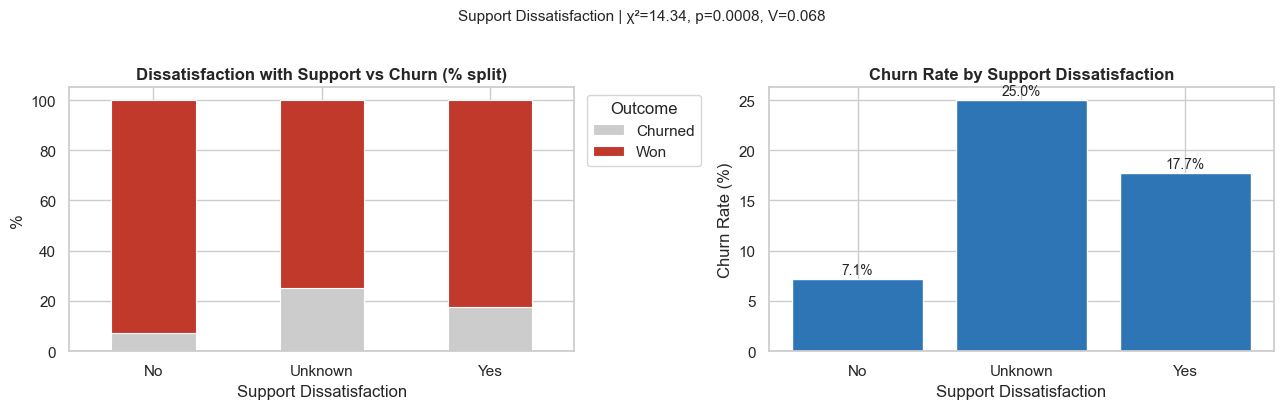

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Dissatisfaction with Support vs Churn (% split)', fontweight='bold')
axes[0].set_xlabel('Support Dissatisfaction')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'],
                   color='#2E75B6', edgecolor='white')
axes[1].set_title('Churn Rate by Support Dissatisfaction', fontweight='bold')
axes[1].set_xlabel('Support Dissatisfaction')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Support Dissatisfaction | χ²={chi2_dis:.2f}, p={p_dis:.4f}, V={v_dis:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 7 — cc_contractor_sentiment — Chi-Square Test

**Feature description:** The overall qualitative sentiment classification of the contractor during the call  
(Satisfied / Neutral / Dissatisfied / Not Discussed).

**H₀:** Contractor sentiment category is independent of churn outcome.  
**H₁:** Contractor sentiment category is significantly associated with churn outcome.

**Test chosen:** Chi-Square — 4-level categorical variable vs binary target.  
Cramér's V measures the overall effect; adjusted standardised residuals identify which cells drive the association.


In [12]:
print('\n' + '='*65)
print('cc_contractor_sentiment × Prospect_Outcome')
print('='*65)

feat = 'cc_contractor_sentiment'
valid_vals = ['Satisfied', 'Neutral', 'Dissatisfied', 'Not Discussed']
sub = df[df[feat].isin(valid_vals)].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_sent, p_sent, dof_sent, expected_sent = chi2_contingency(ct)
v_sent = cramers_v(ct)

print(f'\nChi-Square Statistic: {chi2_sent:.4f}')
print(f'Degrees of Freedom: {dof_sent}')
print(f'p-value: {p_sent:.6f}')
print(f"Cramers V: {v_sent:.4f} ({effect_label(v_sent)})")

observed = ct.values
std_resid = (observed - expected_sent) / np.sqrt(expected_sent)
resid_df = pd.DataFrame(std_resid, index=ct.index, columns=ct.columns)
print('\nStandardised Residuals (|value| > 2 = noteworthy):')
print(resid_df.round(3))

print(f'\n{interpret(p_sent)}')

results.append({'Feature': feat, 'Test': 'Chi-Square', 'Statistic': round(chi2_sent,4),
                'p-value': round(p_sent,6), 'Effect Size': round(v_sent,4),
                'Effect Label': effect_label(v_sent), 'Significant': p_sent < SIG_LEVEL})


cc_contractor_sentiment × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome         Churned   Won
cc_contractor_sentiment               
Dissatisfied                  18    94
Neutral                      117  1160
Not Discussed                 15   181
Satisfied                     83  1469

Row percentages:
Prospect_Outcome         Churned     Won
cc_contractor_sentiment                 
Dissatisfied             16.0700 83.9300
Neutral                   9.1600 90.8400
Not Discussed             7.6500 92.3500
Satisfied                 5.3500 94.6500

Chi-Square Statistic: 27.5348
Degrees of Freedom: 3
p-value: 0.000005
Cramers V: 0.0937 (Negligible)

Standardised Residuals (|value| > 2 = noteworthy):
Prospect_Outcome         Churned     Won
cc_contractor_sentiment                 
Dissatisfied              3.3570 -0.9510
Neutral                   2.2740 -0.6440
Not Discussed             0.1160 -0.0330
Satisfied                -3.0060  0.8510

SIGNIFICANT (p=0.0000 < 0.05

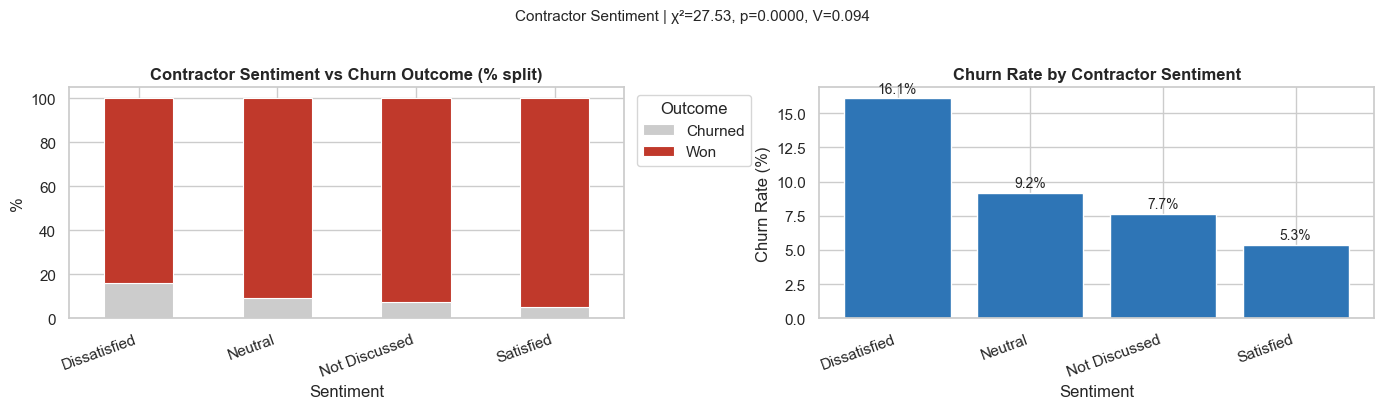

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order = ct_pct['Churned'].sort_values(ascending=False).index
ct_ordered = ct_pct.loc[order]

ct_ordered.plot(kind='bar', stacked=True, ax=axes[0],
                color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Contractor Sentiment vs Churn Outcome (% split)', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_vals = ct_pct.loc[order, 'Churned']
bars = axes[1].bar(churn_vals.index, churn_vals.values, color='#2E75B6', edgecolor='white')
axes[1].set_title('Churn Rate by Contractor Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.suptitle(f'Contractor Sentiment | χ²={chi2_sent:.2f}, p={p_sent:.4f}, V={v_sent:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 8 — cc_contractor_sentiment_issues_score — Mann-Whitney U Test

**Feature description:** A numerical score (0–100) quantifying the severity/intensity of issues raised  
during the call. Contains 'Not Discussed' values which are treated as missing.

**Why not t-test?** The score is discrete with a small set of values (0, 10, 20 … 100),  
heavily right-skewed, and the Churned group has n=78. A Shapiro-Wilk normality test is run first  
to confirm the decision; if non-normal, Mann-Whitney U (rank-based, non-parametric) is used.

**H₀:** The distribution of sentiment issues score is identical for Won and Churned members.  
**H₁:** The distributions differ significantly between Won and Churned members.


In [14]:
print('\n' + '='*65)
print('cc_contractor_sentiment_issues_score × Prospect_Outcome')
print('='*65)

feat = 'cc_contractor_sentiment_issues_score'
won_s = df.loc[df['Prospect_Outcome']=='Won', 'sentiment_score_num'].dropna()
churn_s = df.loc[df['Prospect_Outcome']=='Churned', 'sentiment_score_num'].dropna()

print(f'\nScore Distribution by Outcome Group:')
print(f"Won - n={len(won_s):,}, mean={won_s.mean():.2f}, median={won_s.median():.1f}, std={won_s.std():.2f}")
print(f"Churned - n={len(churn_s):,}, mean={churn_s.mean():.2f}, median={churn_s.median():.1f}, std={churn_s.std():.2f}")

sw_won = shapiro(won_s.sample(min(500, len(won_s)), random_state=42))
sw_churn = shapiro(churn_s)
print(f'\nShapiro-Wilk Normality Test:')
print(f'Won group - W={sw_won.statistic:.4f}, p={sw_won.pvalue:.6f} {"(Normal)" if sw_won.pvalue > 0.05 else "(NOT Normal)"}')
print(f'Churned group - W={sw_churn.statistic:.4f}, p={sw_churn.pvalue:.6f} {"(Normal)" if sw_churn.pvalue > 0.05 else "(NOT Normal)"}')
print('\nUsing Mann-Whitney U (non-parametric) regardless of normality result.')

u_stat, p_mw = mannwhitneyu(won_s, churn_s, alternative='two-sided')

n1, n2 = len(won_s), len(churn_s)
rb_corr = 1 - (2 * u_stat) / (n1 * n2)

print(f'\nMann-Whitney U Statistic: {u_stat:.0f}')
print(f'p-value: {p_mw:.6f}')
print(f'Rank-Biserial r: {rb_corr:.4f} ({effect_label(rb_corr, "rb")})')
print(f'\n{interpret(p_mw)}')

results.append({'Feature': feat, 'Test': 'Mann-Whitney U', 'Statistic': round(u_stat,4),
                'p-value': round(p_mw,6), 'Effect Size': round(rb_corr,4),
                'Effect Label': effect_label(rb_corr,'rb'), 'Significant': p_mw < SIG_LEVEL})


cc_contractor_sentiment_issues_score × Prospect_Outcome

Score Distribution by Outcome Group:
Won - n=1,007, mean=80.45, median=85.0, std=16.03
Churned - n=78, mean=68.97, median=80.0, std=24.92

Shapiro-Wilk Normality Test:
Won group - W=0.6990, p=0.000000 (NOT Normal)
Churned group - W=0.7858, p=0.000000 (NOT Normal)

Using Mann-Whitney U (non-parametric) regardless of normality result.

Mann-Whitney U Statistic: 52298
p-value: 0.000000
Rank-Biserial r: -0.3317 (Medium)

SIGNIFICANT (p=0.0000 < 0.05)


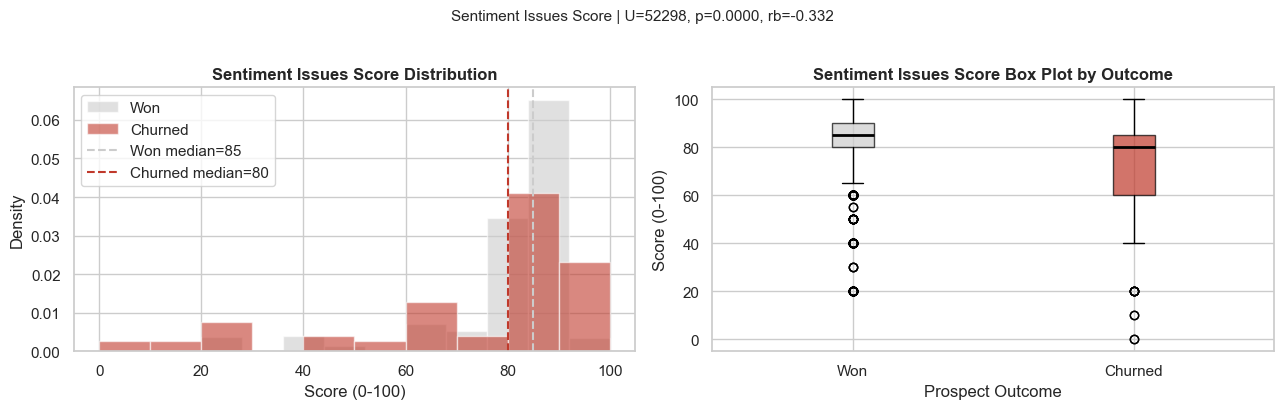

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(won_s, bins=10, alpha=0.6, color='#CCCCCC', label='Won', density=True, edgecolor='white')
axes[0].hist(churn_s, bins=10, alpha=0.6, color='#C0392B', label='Churned', density=True, edgecolor='white')
axes[0].axvline(won_s.median(), color='#CCCCCC', linestyle='--', linewidth=1.5,
                label=f'Won median={won_s.median():.0f}')
axes[0].axvline(churn_s.median(), color='#C0392B', linestyle='--', linewidth=1.5,
                label=f'Churned median={churn_s.median():.0f}')
axes[0].set_title('Sentiment Issues Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Density')
axes[0].legend()

score_df = pd.DataFrame({'Score': pd.concat([won_s, churn_s]),
                          'Outcome': ['Won']*len(won_s)+['Churned']*len(churn_s)})
bp = axes[1].boxplot([won_s, churn_s], labels=['Won', 'Churned'],
                     patch_artist=True, medianprops={'color':'black','linewidth':2})
bp['boxes'][0].set_facecolor('#CCCCCC')
bp['boxes'][1].set_facecolor('#C0392B')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
axes[1].set_title('Sentiment Issues Score Box Plot by Outcome', fontweight='bold')
axes[1].set_xlabel('Prospect Outcome')
axes[1].set_ylabel('Score (0-100)')

plt.suptitle(f'Sentiment Issues Score | U={u_stat:.0f}, p={p_mw:.4f}, rb={rb_corr:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 9 — cc_pricing_sentiment_impact — Chi-Square + Fisher's Exact

**Feature description:** Whether pricing discussion had a notable sentiment impact during the call (Yes / No).

**H₀:** Pricing sentiment impact is independent of churn outcome.  
**H₁:** Pricing sentiment impact is significantly associated with churn outcome.

**Test chosen:** Both Chi-Square and Fisher's Exact are run on the 2×2 table.  
Fisher's Exact is exact (no approximation) and preferred when any expected cell count < 5.


In [16]:
print('\n' + '='*65)
print("cc_pricing_sentiment_impact × Prospect_Outcome")
print('='*65)

feat = 'cc_pricing_sentiment_impact'
sub = df[df[feat].isin(['Yes','No'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_p, p_p, dof_p, exp_p = chi2_contingency(ct)
v_p = cramers_v(ct)

table_2x2 = np.array([[ct.loc['No','Won'], ct.loc['No','Churned']],
                       [ct.loc['Yes','Won'], ct.loc['Yes','Churned']]])
odds_ratio, p_fisher = fisher_exact(table_2x2)

print(f'\nChi-Square Test:')
print(f'χ² = {chi2_p:.4f}, df = {dof_p}, p = {p_p:.6f}')
print(f"Cramers V = {v_p:.4f} ({effect_label(v_p)})")
print(f'Min expected cell = {exp_p.min():.2f}')
print(f"\nFisher's Exact Test:")
print(f'Odds Ratio = {odds_ratio:.4f}')
print(f'p-value = {p_fisher:.6f}')
print(f'\n{interpret(p_p)} [Chi-Square]')
print(f'{interpret(p_fisher)} [Fisher Exact]')

results.append({'Feature': feat, 'Test': "Chi-Sq + Fisher's Exact", 'Statistic': round(chi2_p,4),
                'p-value': round(p_p,6), 'Effect Size': round(v_p,4),
                'Effect Label': effect_label(v_p), 'Significant': p_p < SIG_LEVEL})


cc_pricing_sentiment_impact × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome             Churned   Won
cc_pricing_sentiment_impact               
No                               210  2769
Yes                               23   135

Row percentages:
Prospect_Outcome             Churned     Won
cc_pricing_sentiment_impact                 
No                            7.0500 92.9500
Yes                          14.5600 85.4400

Chi-Square Test:
χ² = 11.2320, df = 1, p = 0.000804
Cramers V = 0.0598 (Negligible)
Min expected cell = 11.74

Fisher's Exact Test:
Odds Ratio = 2.2465
p-value = 0.001487

SIGNIFICANT (p=0.0008 < 0.05) [Chi-Square]
SIGNIFICANT (p=0.0015 < 0.05) [Fisher Exact]


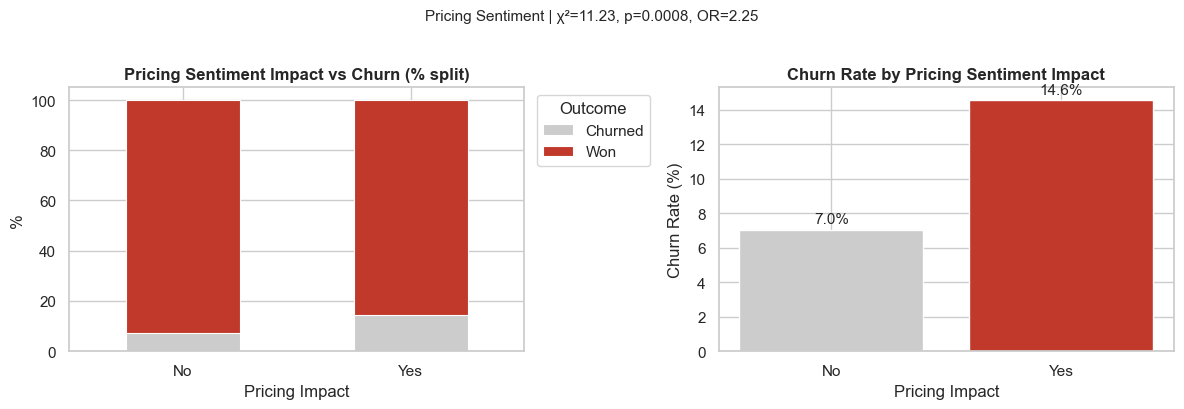

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Pricing Sentiment Impact vs Churn (% split)', fontweight='bold')
axes[0].set_xlabel('Pricing Impact')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
colors = ['#C0392B' if c=='Yes' else '#CCCCCC' for c in churn_rate[feat]]
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'], color=colors, edgecolor='white')
axes[1].set_title('Churn Rate by Pricing Sentiment Impact', fontweight='bold')
axes[1].set_xlabel('Pricing Impact')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle(f'Pricing Sentiment | χ²={chi2_p:.2f}, p={p_p:.4f}, OR={odds_ratio:.2f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 10 — cc_refund_discussed — Chi-Square + Fisher's Exact

**Feature description:** Whether a refund was discussed during the customer care call (Yes / No).

**H₀:** Refund discussion is independent of churn outcome.  
**H₁:** Refund discussion is significantly associated with churn outcome.

**Test chosen:** Chi-Square + Fisher's Exact (2×2 table).


In [18]:
print('\n' + '='*65)
print("cc_refund_discussed × Prospect_Outcome")
print('='*65)

feat = 'cc_refund_discussed'
sub = df[df[feat].isin(['Yes','No'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_r, p_r, dof_r, exp_r = chi2_contingency(ct)
v_r = cramers_v(ct)

table_2x2 = np.array([[ct.loc['No','Won'], ct.loc['No','Churned']],
                       [ct.loc['Yes','Won'], ct.loc['Yes','Churned']]])
or_r, p_fisher_r = fisher_exact(table_2x2)

print(f'\nChi-Square Test:')
print(f'χ² = {chi2_r:.4f}, df = {dof_r}, p = {p_r:.6f}')
print(f"Cramers V = {v_r:.4f} ({effect_label(v_r)})")
print(f'Min expected cell = {exp_r.min():.2f}')
print(f"\nFisher's Exact Test:")
print(f'Odds Ratio = {or_r:.4f}')
print(f'p-value = {p_fisher_r:.6f}')
print(f'\n{interpret(p_r)} [Chi-Square]')
print(f'{interpret(p_fisher_r)} [Fisher Exact]')

results.append({'Feature': feat, 'Test': "Chi-Sq + Fisher's Exact", 'Statistic': round(chi2_r,4),
                'p-value': round(p_r,6), 'Effect Size': round(v_r,4),
                'Effect Label': effect_label(v_r), 'Significant': p_r < SIG_LEVEL})


cc_refund_discussed × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome     Churned   Won
cc_refund_discussed               
No                       228  2891
Yes                        5    13

Row percentages:
Prospect_Outcome     Churned     Won
cc_refund_discussed                 
No                    7.3100 92.6900
Yes                  27.7800 72.2200

Chi-Square Test:
χ² = 8.1305, df = 1, p = 0.004353
Cramers V = 0.0509 (Negligible)
Min expected cell = 1.34

Fisher's Exact Test:
Odds Ratio = 4.8769
p-value = 0.008318

SIGNIFICANT (p=0.0044 < 0.05) [Chi-Square]
SIGNIFICANT (p=0.0083 < 0.05) [Fisher Exact]


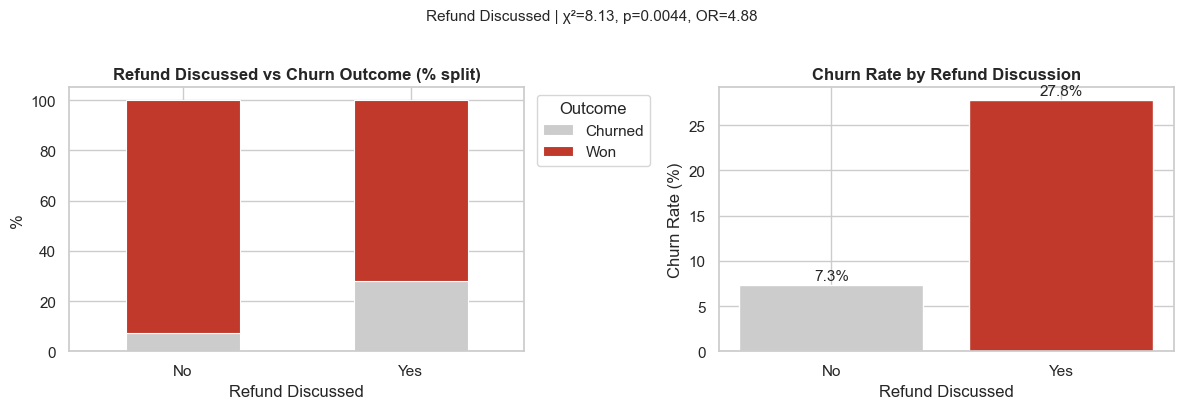

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Refund Discussed vs Churn Outcome (% split)', fontweight='bold')
axes[0].set_xlabel('Refund Discussed')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
colors = ['#C0392B' if c=='Yes' else '#CCCCCC' for c in churn_rate[feat]]
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'], color=colors, edgecolor='white')
axes[1].set_title('Churn Rate by Refund Discussion', fontweight='bold')
axes[1].set_xlabel('Refund Discussed')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle(f'Refund Discussed | χ²={chi2_r:.2f}, p={p_r:.4f}, OR={or_r:.2f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 11 — cc_contractor_complained — Chi-Square + Fisher's Exact

**Feature description:** Whether the contractor made a complaint (formal or informal) during the call (Yes / No).

**H₀:** Complaint behaviour is independent of churn outcome.  
**H₁:** Complaint behaviour is significantly associated with churn outcome.

**Test chosen:** Chi-Square + Fisher's Exact (2×2 table).


In [20]:
print('\n' + '='*65)
print("cc_contractor_complained × Prospect_Outcome")
print('='*65)

feat = 'cc_contractor_complained'
sub = df[df[feat].isin(['Yes','No'])].copy()

ct = pd.crosstab(sub[feat], sub['Prospect_Outcome'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('\nContingency Table (counts):')
print(ct)
print('\nRow percentages:')
print(ct_pct.round(2))

chi2_c, p_c, dof_c, exp_c = chi2_contingency(ct)
v_c = cramers_v(ct)

table_2x2 = np.array([[ct.loc['No','Won'], ct.loc['No','Churned']],
                       [ct.loc['Yes','Won'], ct.loc['Yes','Churned']]])
or_c, p_fisher_c = fisher_exact(table_2x2)

print(f'\nChi-Square Test:')
print(f'χ² = {chi2_c:.4f}, df = {dof_c}, p = {p_c:.6f}')
print(f"Cramers V = {v_c:.4f} ({effect_label(v_c)})")
print(f'Min expected cell = {exp_c.min():.2f}')
print(f"\nFisher's Exact Test:")
print(f'Odds Ratio = {or_c:.4f}')
print(f'p-value = {p_fisher_c:.6f}')
print(f'\n{interpret(p_c)} [Chi-Square]')
print(f'{interpret(p_fisher_c)} [Fisher Exact]')

results.append({'Feature': feat, 'Test': "Chi-Sq + Fisher's Exact", 'Statistic': round(chi2_c,4),
                'p-value': round(p_c,6), 'Effect Size': round(v_c,4),
                'Effect Label': effect_label(v_c), 'Significant': p_c < SIG_LEVEL})


cc_contractor_complained × Prospect_Outcome

Contingency Table (counts):
Prospect_Outcome          Churned   Won
cc_contractor_complained               
No                            209  2704
Yes                            24   200

Row percentages:
Prospect_Outcome          Churned     Won
cc_contractor_complained                 
No                         7.1700 92.8300
Yes                       10.7100 89.2900

Chi-Square Test:
χ² = 3.2928, df = 1, p = 0.069586
Cramers V = 0.0324 (Negligible)
Min expected cell = 16.64

Fisher's Exact Test:
Odds Ratio = 1.5525
p-value = 0.062791

NOT SIGNIFICANT (p=0.0696 >= 0.05) [Chi-Square]
NOT SIGNIFICANT (p=0.0628 >= 0.05) [Fisher Exact]


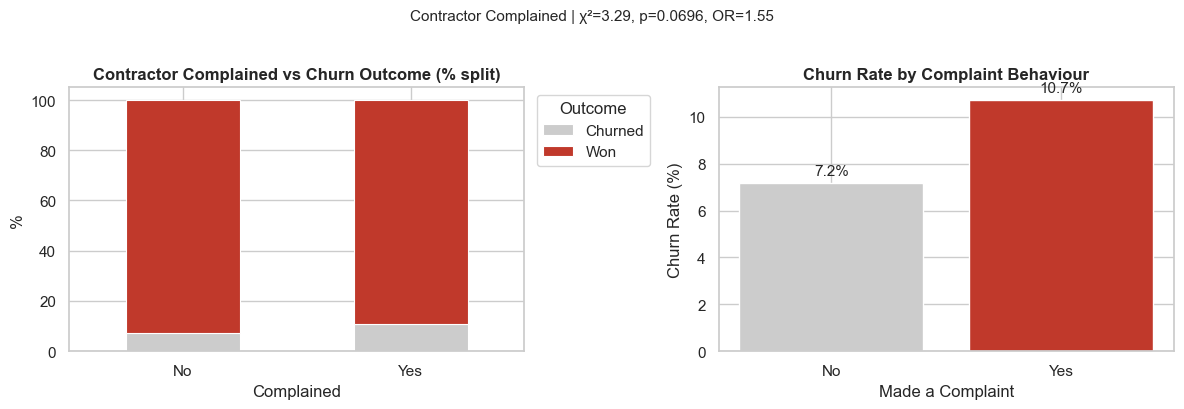

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#CCCCCC', '#C0392B'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Contractor Complained vs Churn Outcome (% split)', fontweight='bold')
axes[0].set_xlabel('Complained')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

churn_rate = ct_pct['Churned'].reset_index()
colors = ['#C0392B' if c=='Yes' else '#CCCCCC' for c in churn_rate[feat]]
bars = axes[1].bar(churn_rate[feat], churn_rate['Churned'], color=colors, edgecolor='white')
axes[1].set_title('Churn Rate by Complaint Behaviour', fontweight='bold')
axes[1].set_xlabel('Made a Complaint')
axes[1].set_ylabel('Churn Rate (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle(f'Contractor Complained | χ²={chi2_c:.2f}, p={p_c:.4f}, OR={or_c:.2f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Section 12 — Summary Results Table

All hypothesis test results consolidated into a single summary table, sorted by effect size descending.

**Interpretation guide:**  
- Significant (p < 0.05) → statistically significant association with churn  
- Not Significant (p ≥ 0.05) → no significant association detected  
- Effect Size: Cramér's V (categorical) or Rank-Biserial r (continuous)


In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Effect Size', ascending=False).reset_index(drop=True)
results_df.index += 1

results_df['Significant'] = results_df['Significant'].map({True: 'Yes', False: 'No'})

print('\n' + '='*80)
print('HYPOTHESIS TESTING SUMMARY - Prospect_Outcome (Won / Churned)')
print('='*80)
print(results_df[['Feature','Test','Statistic','p-value','Effect Size','Effect Label','Significant']]
      .to_string(index=True))
print('='*80)
sig_count = (results_df['Significant'] == 'Yes').sum()
print(f'\nSignificant features: {sig_count} / {len(results_df)}')
print(f'Significance level: α = 0.05')


HYPOTHESIS TESTING SUMMARY - Prospect_Outcome (Won / Churned)
                                    Feature                     Test  Statistic  p-value  Effect Size Effect Label Significant
1  cc_business_struggles_financial_hardship               Chi-Square    53.5764   0.0000       0.1307        Small         Yes
2                   cc_contractor_sentiment               Chi-Square    27.5348   0.0000       0.0937   Negligible         Yes
3                cc_dissatisfaction_support               Chi-Square    14.3433   0.0008       0.0676   Negligible         Yes
4               cc_pricing_sentiment_impact  Chi-Sq + Fisher's Exact    11.2320   0.0008       0.0598   Negligible         Yes
5                       cc_refund_discussed  Chi-Sq + Fisher's Exact     8.1305   0.0044       0.0509   Negligible         Yes
6                  cc_contractor_complained  Chi-Sq + Fisher's Exact     3.2928   0.0696       0.0324   Negligible          No
7                                 Direction     

## Section 13 — Visualisation Dashboard

A consolidated view of all feature p-values and effect sizes side-by-side.


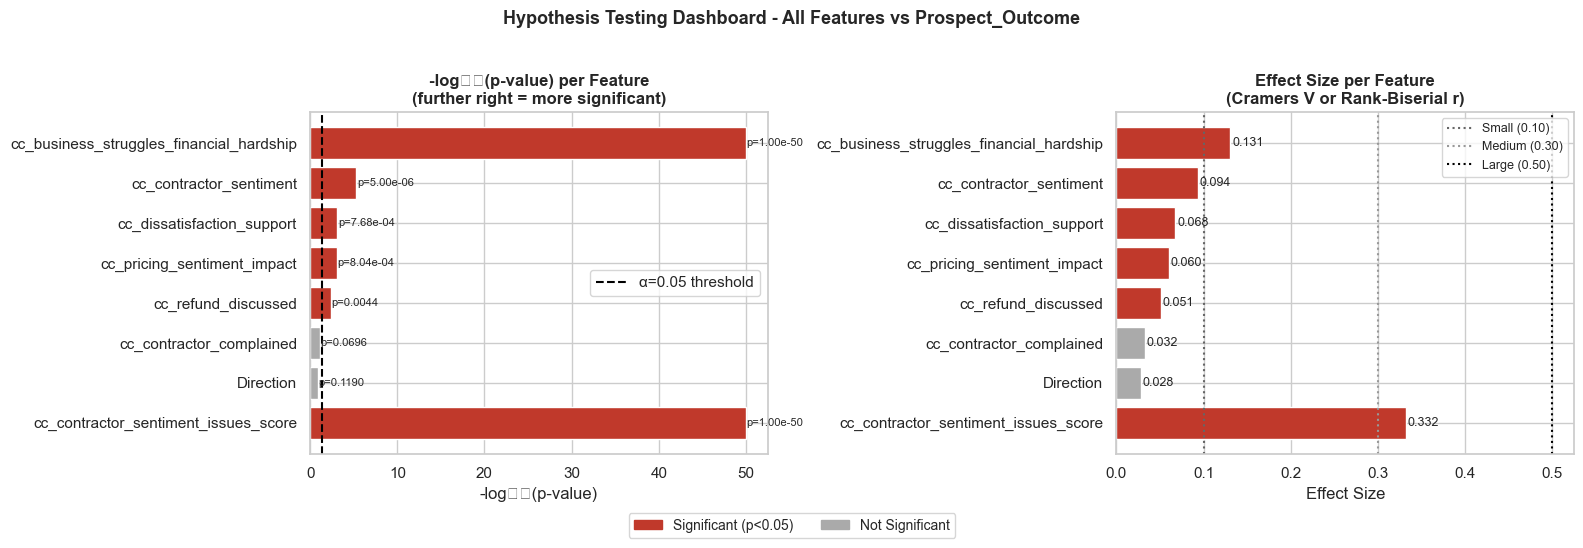

In [23]:
res = pd.DataFrame(results).sort_values('Effect Size', ascending=True)
res['Significant_bool'] = res['p-value'] < SIG_LEVEL
bar_colors = ['#C0392B' if s else '#AAAAAA' for s in res['Significant_bool']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

p_vals = res['p-value'].clip(lower=1e-50)
bars1 = axes[0].barh(res['Feature'], -np.log10(p_vals), color=bar_colors, edgecolor='white')
axes[0].axvline(-np.log10(SIG_LEVEL), color='black', linestyle='--', linewidth=1.5,
                label=f'α={SIG_LEVEL} threshold')
axes[0].set_title('-log₁₀(p-value) per Feature\n(further right = more significant)',
                  fontweight='bold')
axes[0].set_xlabel('-log₁₀(p-value)')
axes[0].legend()
for bar, pv in zip(bars1, p_vals):
    lbl = f'p={pv:.2e}' if pv < 0.001 else f'p={pv:.4f}'
    axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                 lbl, va='center', fontsize=8)

bars2 = axes[1].barh(res['Feature'], res['Effect Size'].abs(), color=bar_colors, edgecolor='white')
axes[1].axvline(0.10, color='#666666', linestyle=':', linewidth=1.5, label='Small (0.10)')
axes[1].axvline(0.30, color='#999999', linestyle=':', linewidth=1.5, label='Medium (0.30)')
axes[1].axvline(0.50, color='#000000', linestyle=':', linewidth=1.5, label='Large (0.50)')
axes[1].set_title("Effect Size per Feature\n(Cramers V or Rank-Biserial r)",
                  fontweight='bold')
axes[1].set_xlabel('Effect Size')
axes[1].legend(fontsize=9)
for bar, ev in zip(bars2, res['Effect Size'].abs()):
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{ev:.3f}', va='center', fontsize=9)

import matplotlib.patches as mpatches
sig_patch = mpatches.Patch(color='#C0392B', label='Significant (p<0.05)')
ns_patch = mpatches.Patch(color='#AAAAAA', label='Not Significant')
fig.legend(handles=[sig_patch, ns_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Hypothesis Testing Dashboard - All Features vs Prospect_Outcome',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## End of Hypothesis Testing Report

**Key Takeaway:** Features with significant p-values and non-negligible effect sizes  
should be prioritised in the churn prediction model. Effect size matters as much as significance —  
large datasets can produce highly significant p-values for practically trivial associations.
